In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
def train_and_evaluate(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    
    return model

In [14]:
df = pd.read_csv("../ressources/dataset.csv", sep=";")
X = df.iloc[:, :-2]  # 18 features

In [15]:
y = df["x_wins"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


=== Decision Tree - x_wins ===
              precision    recall  f1-score   support

           0       0.66      0.45      0.53       204
           1       0.77      0.89      0.82       424

    accuracy                           0.75       628
   macro avg       0.71      0.67      0.68       628
weighted avg       0.73      0.75      0.73       628



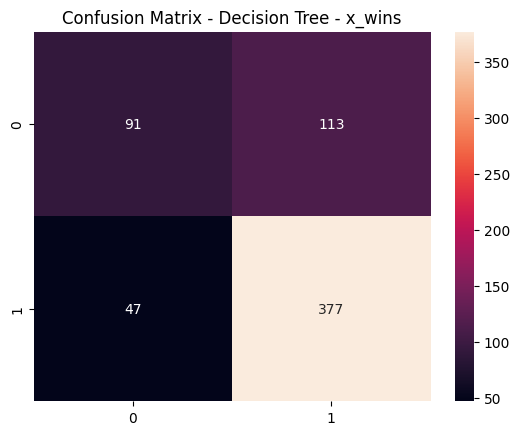

In [16]:
dt_x = train_and_evaluate(DecisionTreeClassifier(max_depth=5), X_train, X_test, y_train, y_test, "Decision Tree - x_wins")


=== Random Forest - x_wins ===
              precision    recall  f1-score   support

           0       0.98      0.59      0.74       204
           1       0.84      0.99      0.91       424

    accuracy                           0.86       628
   macro avg       0.91      0.79      0.82       628
weighted avg       0.88      0.86      0.85       628



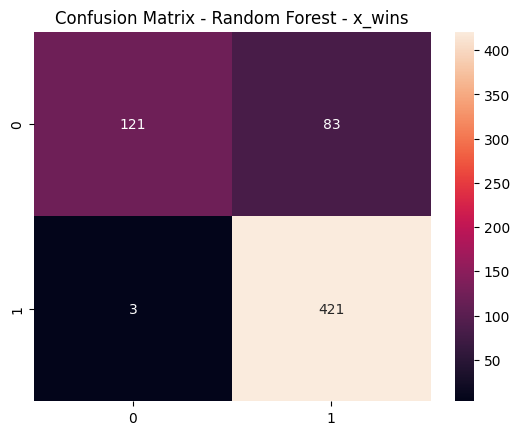

In [17]:
rf_x = train_and_evaluate(RandomForestClassifier(n_estimators=100), X_train, X_test, y_train, y_test, "Random Forest - x_wins")


=== Gradient Boosting - x_wins ===
              precision    recall  f1-score   support

           0       0.80      0.44      0.57       204
           1       0.78      0.95      0.85       424

    accuracy                           0.78       628
   macro avg       0.79      0.69      0.71       628
weighted avg       0.78      0.78      0.76       628



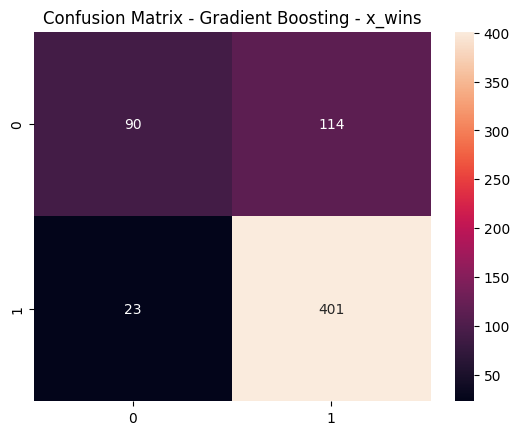

In [18]:
gb_x = train_and_evaluate(GradientBoostingClassifier(), X_train, X_test, y_train, y_test, "Gradient Boosting - x_wins")


=== MLP - x_wins ===
              precision    recall  f1-score   support

           0       0.93      0.82      0.87       204
           1       0.92      0.97      0.94       424

    accuracy                           0.92       628
   macro avg       0.93      0.90      0.91       628
weighted avg       0.92      0.92      0.92       628



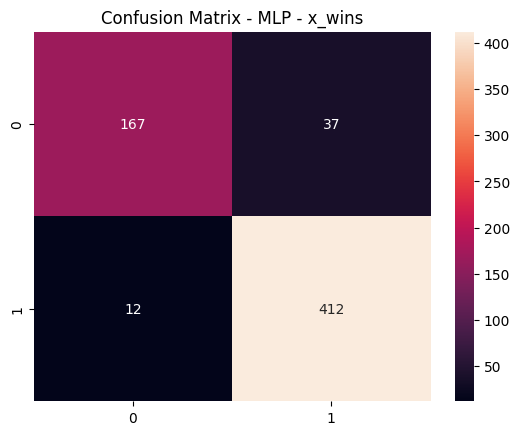

In [19]:
mlp_x = train_and_evaluate(MLPClassifier(hidden_layer_sizes=(50,50), max_iter=500), X_train, X_test, y_train, y_test, "MLP - x_wins")

In [20]:
y = df["is_draw"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


=== Random Forest - is_draw ===
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       550
           1       0.93      0.35      0.50        78

    accuracy                           0.92       628
   macro avg       0.92      0.67      0.73       628
weighted avg       0.92      0.92      0.90       628



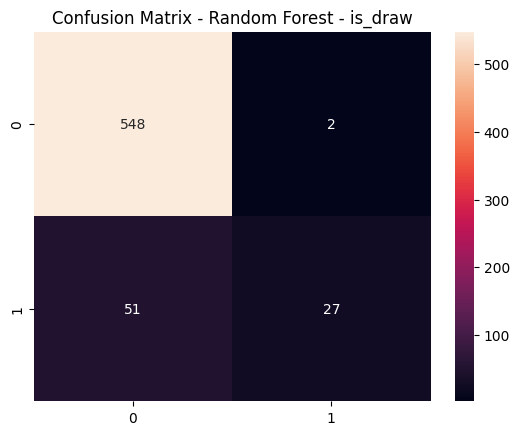

In [21]:
rf_d = train_and_evaluate(RandomForestClassifier(n_estimators=100, class_weight="balanced"), X_train, X_test, y_train, y_test, "Random Forest - is_draw")


=== Gradient Boosting - is_draw ===
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       550
           1       0.86      0.32      0.47        78

    accuracy                           0.91       628
   macro avg       0.89      0.66      0.71       628
weighted avg       0.91      0.91      0.89       628



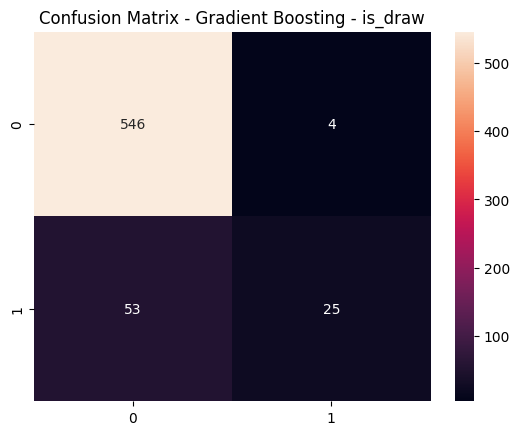

In [22]:
gb_d = train_and_evaluate(GradientBoostingClassifier(), X_train, X_test, y_train, y_test, "Gradient Boosting - is_draw")


=== Gradient Boosting - is_draw ===
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       550
           1       0.86      0.32      0.47        78

    accuracy                           0.91       628
   macro avg       0.89      0.66      0.71       628
weighted avg       0.91      0.91      0.89       628



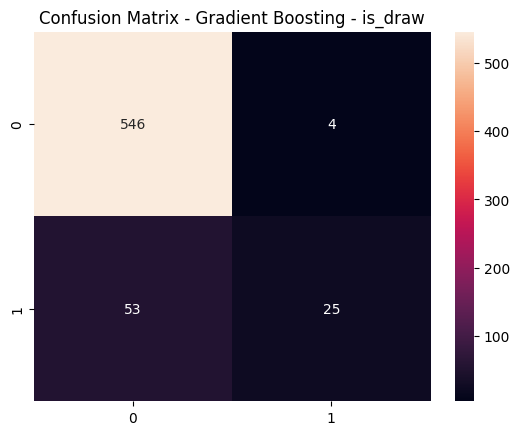

In [23]:
gb_d = train_and_evaluate(GradientBoostingClassifier(), X_train, X_test, y_train, y_test, "Gradient Boosting - is_draw")

In [24]:
importances = rf_x.feature_importances_
feat_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print(feat_importance.head(10))

c4_o    0.084298
c6_o    0.072842
c2_o    0.067638
c8_o    0.066881
c0_o    0.063317
c1_o    0.057523
c3_o    0.054714
c6_x    0.053512
c5_o    0.053024
c2_x    0.052156
dtype: float64


In [28]:
import joblib
joblib.dump(rf_x, "../models/model_xwins.pkl")
joblib.dump(rf_d, "../models/model_draw.pkl")

['../models/model_draw.pkl']